## ESTUDIO DE EEG DEL FUNCIONAMIENTO PARA EL CONTROL DEL MOVIMIENTO CON ENFOQUE EN EVALUACIÓN DE SISTEMAS DE INTERFAZ CEREBRO-COMPUTADORA (BCI)
#### **Autoras:** [Luisa Fernanda Llamas Baldovino, Camila Andrea Montiel Zapata]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import glob
import os

# 1. Definir la ruta del archivo (Asegúrate de poner la ruta correcta donde tengas el archivo S099R02.edf)
# Ejemplo: r"C:/Users/TuUsuario/Desktop/S099R02.edf"
ruta_edf = r"S099R02.edf" 

# 2. Leer el archivo .edf usando MNE (se cambia read_raw_eeglab por read_raw_edf)
raw_S099 = mne.io.read_raw_edf(ruta_edf, preload=True)

# 3. Imprimir la información general de la señal (metadata)
print(raw_S099.info)

# 4. Extraer y mostrar los nombres de los canales
canales_eeg_S099 = raw_S099.ch_names
print("Canales disponibles en el archivo:")
print(canales_eeg_S099)

Extracting EDF parameters from S099R02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Canales disponibles en el archivo:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.

Using matplotlib as 2D backend.


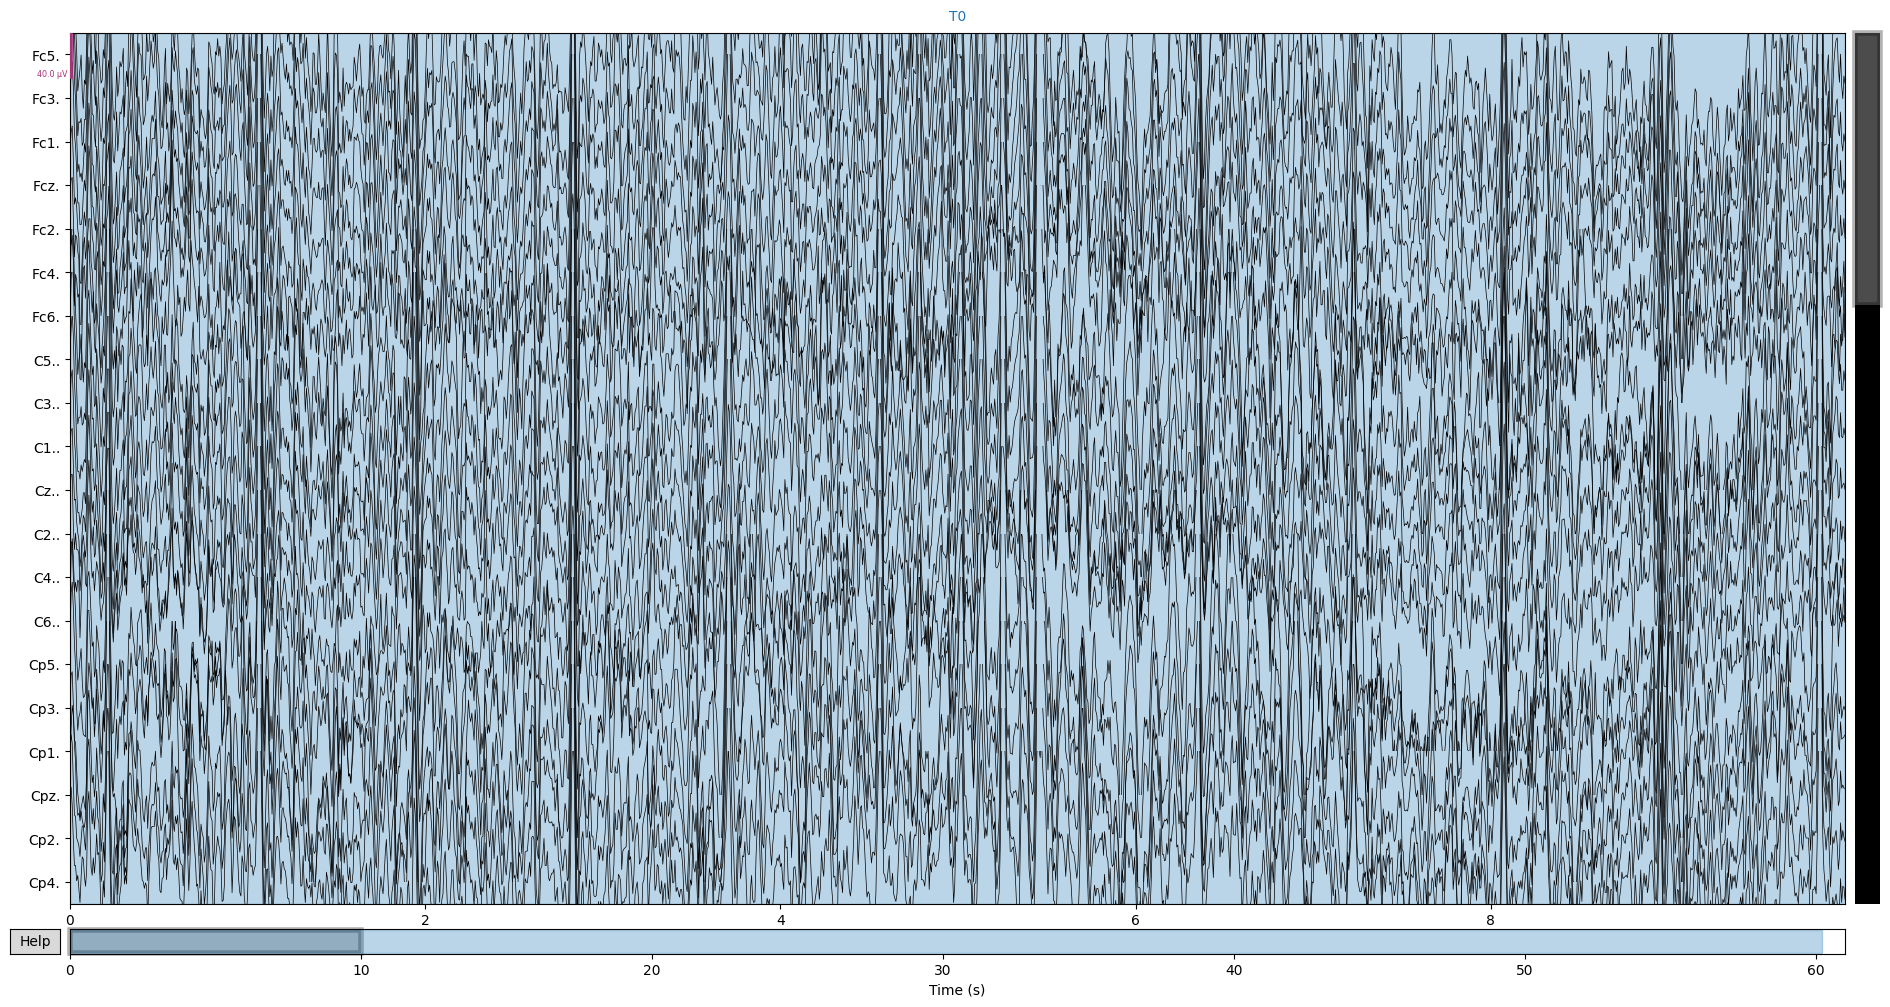

In [3]:
%matplotlib qt
raw_S099.plot()

In [13]:
import os, glob
import os, glob
import numpy as np
import matplotlib
# matplotlib.use('Agg')  # Descomenta si corres en servidor/terminal sin pantalla
# En Windows con Spyder/Jupyter esta línea NO es necesaria
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
from scipy import signal as sp_signal
import mne
 
# ── Paleta de colores del proyecto ──────────────────────────
C_RAW   = '#E74C3C'
C_CAR   = '#E67E22'
C_FILT  = '#2ECC71'
C_EPOCH = '#3498DB'
C_PSD   = '#9B59B6'
C_MU    = '#1ABC9C'
C_BETA  = '#F39C12'
C_T1    = '#2980B9'
C_T2    = '#C0392B'
C_REST  = '#7F8C8D'
 
BANDAS = {
    'Delta (0.5–4 Hz)':  (0.5, 4),
    'Theta (4–8 Hz)':    (4,   8),
    'Mu (8–12 Hz)':      (8,  12),
    'Beta (13–30 Hz)':   (13, 30),
    'Gamma (30–45 Hz)':  (30, 45),
}
 
CANALES_INTERES = ['C3', 'Cz', 'C4']
OUT = os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd(), 'figuras_BCI')
os.makedirs(OUT, exist_ok=True)

In [14]:
# =====================================================================
# 1.  FUNCIÓN DE PROCESAMIENTO  (flujo BCI completo)
# =====================================================================
def procesar_flujo_bci(ruta_edf, verbose=False):
    """
    Aplica el pipeline completo: CAR → Filtro FIR (8-30 Hz) → Epochs → Welch PSD.
    Retorna un dict con cada fase para poder graficarlas.
    """
    v = 'WARNING' if not verbose else None
 
    # ── Fase 0: Señal cruda ──────────────────────────────────
    raw = mne.io.read_raw_edf(ruta_edf, preload=True, verbose=v)
    raw.rename_channels(lambda x: x.strip('.'))
 
    # ── Fase 1: CAR (Common Average Reference) ───────────────
    raw_car, _ = mne.set_eeg_reference(raw, ref_channels='average',
                                        copy=True, verbose=v)
 
    # ── Fase 2: Filtro FIR pasa-banda 8–30 Hz ────────────────
    raw_filt = raw_car.copy().filter(
        l_freq=8.0, h_freq=30.0,
        method='fir', phase='zero', verbose=v
    )
 
    # ── Fase 3: Segmentación en épocas ───────────────────────
    events, event_id = mne.events_from_annotations(raw_filt, verbose=v)
    epochs = mne.Epochs(
        raw_filt, events,
        tmin=-0.2, tmax=1.0,
        baseline=(None, 0),
        preload=True, verbose=v
    )
 
    # ── Fase 4: Welch PSD ────────────────────────────────────
    spectrum = epochs.compute_psd(
        method='welch', fmin=8.0, fmax=30.0, verbose=v
    )
 
    return {
        'raw':      raw,
        'car':      raw_car,
        'filtered': raw_filt,
        'epochs':   epochs,
        'spectrum': spectrum,
        'event_id': event_id,
    }

In [15]:
# =====================================================================
# 2.  GRÁFICA 1 — Señal en cada fase (dominio del tiempo)
# =====================================================================
def fig_fases_tiempo(resultado, sujeto, tarea, canal='C3',
                     t_start=20.0, duracion=4.0):
    """
    5 paneles verticales: cruda / CAR / filtrada / épocas superpuestas / PSD media.
    """
    sfreq = resultado['raw'].info['sfreq']
    i0    = int(t_start * sfreq)
    i1    = int((t_start + duracion) * sfreq)
 
    def get_ch(raw_obj, ch):
        idx = raw_obj.ch_names.index(ch)
        return raw_obj.get_data()[idx]
 
    sig_raw  = get_ch(resultado['raw'],      canal)[i0:i1] * 1e6
    sig_car  = get_ch(resultado['car'],      canal)[i0:i1] * 1e6
    sig_filt = get_ch(resultado['filtered'], canal)[i0:i1] * 1e6
    tv       = np.linspace(0, duracion, len(sig_raw))
 
    # Épocas del canal de interés
    epochs = resultado['epochs']
    if canal in epochs.ch_names:
        ch_idx = epochs.ch_names.index(canal)
        ep_data = epochs.get_data()[:, ch_idx, :] * 1e6
        t_ep    = epochs.times
    else:
        ep_data = None
 
    # PSD de la señal filtrada en el canal
    f_psd, psd_vals = sp_signal.welch(
        get_ch(resultado['filtered'], canal),
        fs=sfreq, nperseg=512, scaling='density'
    )
    psd_vals *= 1e12  # µV²/Hz
 
    fig = plt.figure(figsize=(14, 16))
    fig.patch.set_facecolor('#0D1117')
    gs  = gridspec.GridSpec(5, 1, figure=fig, hspace=0.55)
 
    fases = [
        ('① Señal cruda',              tv, sig_raw,  C_RAW,   'µV'),
        ('② Tras CAR (referencia media)', tv, sig_car,  C_CAR,   'µV'),
        ('③ Tras filtro FIR 8–30 Hz',  tv, sig_filt, C_FILT,  'µV'),
    ]
 
    for i, (titulo, x, y, color, unit) in enumerate(fases):
        ax = fig.add_subplot(gs[i])
        ax.set_facecolor('#161B22')
        ax.plot(x, y, color=color, lw=0.9, alpha=0.92)
        ax.fill_between(x, y, alpha=0.08, color=color)
        ax.set_ylabel(unit, color='#8B949E', fontsize=9)
        ax.set_title(titulo, color=color, fontsize=11, fontweight='bold',
                     loc='left', pad=4)
        ax.tick_params(colors='#8B949E', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363D')
        rms = np.sqrt(np.mean(y**2))
        ax.annotate(f'RMS={rms:.2f} µV  |  pp={y.max()-y.min():.1f} µV',
                    xy=(0.98, 0.88), xycoords='axes fraction',
                    ha='right', fontsize=8, color='#8B949E')
        ax.grid(True, alpha=0.15, lw=0.5, color='#30363D')
 
    # Panel 4: épocas superpuestas
    ax4 = fig.add_subplot(gs[3])
    ax4.set_facecolor('#161B22')
    if ep_data is not None:
        for ep in ep_data:
            ax4.plot(t_ep, ep, color=C_EPOCH, lw=0.5, alpha=0.25)
        ax4.plot(t_ep, ep_data.mean(axis=0), color='white', lw=1.6,
                 label='Promedio', zorder=5)
        ax4.axvline(0, color='#F1FA8C', lw=1.2, ls='--', label='Onset')
        ax4.legend(fontsize=8, facecolor='#161B22', labelcolor='white', framealpha=0.5)
        ax4.set_ylabel('µV', color='#8B949E', fontsize=9)
    ax4.set_title('④ Épocas segmentadas (canal ' + canal + ')',
                  color=C_EPOCH, fontsize=11, fontweight='bold', loc='left', pad=4)
    ax4.tick_params(colors='#8B949E', labelsize=8)
    for spine in ax4.spines.values():
        spine.set_edgecolor('#30363D')
    ax4.grid(True, alpha=0.15, lw=0.5, color='#30363D')
 
    # Panel 5: PSD con bandas sombreadas
    ax5 = fig.add_subplot(gs[4])
    ax5.set_facecolor('#161B22')
    mask = (f_psd >= 1) & (f_psd <= 45)
    ax5.semilogy(f_psd[mask], psd_vals[mask], color=C_PSD, lw=1.3)
    ax5.fill_between(f_psd[mask], psd_vals[mask], alpha=0.15, color=C_PSD)
 
    shade_info = [
        (0.5,4,'#FF6B6B','Δ'), (4,8,'#FFB347','Θ'),
        (8,12,'#51CF66','Mu'), (13,30,'#74C0FC','β'), (30,45,'#CC5DE8','γ')
    ]
    ylims = ax5.get_ylim()
    for f0, f1, col, lbl in shade_info:
        ax5.axvspan(f0, f1, alpha=0.10, color=col)
        ax5.text((f0+f1)/2, psd_vals[mask].max()*0.7, lbl,
                 ha='center', fontsize=8, color=col, fontweight='bold')
    ax5.axvline(60, color='#FF6B6B', lw=0.8, ls=':', alpha=0.6)
    ax5.set_ylabel('µV²/Hz', color='#8B949E', fontsize=9)
    ax5.set_xlabel('Frecuencia (Hz)', color='#8B949E', fontsize=9)
    ax5.set_title('⑤ Densidad Espectral de Potencia (Welch)',
                  color=C_PSD, fontsize=11, fontweight='bold', loc='left', pad=4)
    ax5.tick_params(colors='#8B949E', labelsize=8)
    for spine in ax5.spines.values():
        spine.set_edgecolor('#30363D')
    ax5.grid(True, alpha=0.15, lw=0.5, color='#30363D', which='both')
    ax5.set_xlim([1, 45])
 
    fig.suptitle(
        f'Flujo de Procesamiento BCI  ·  {sujeto}  ·  {tarea}  ·  Canal {canal}',
        color='white', fontsize=13, fontweight='bold', y=0.995
    )
 
    path = f'{OUT}/{sujeto}_{tarea.replace(" ","_")}_fases_tiempo_{canal}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    print(f'  → {path}')
    return path

In [16]:
# =====================================================================
# 3.  GRÁFICA 2 — Efecto de los filtros en el espectro
# =====================================================================
def fig_espectros_fases(resultado, sujeto, tarea, canal='C3'):
    """
    Superposición de PSD en cada etapa: muestra qué elimina cada filtro.
    """
    sfreq = resultado['raw'].info['sfreq']
 
    def psd_canal(raw_obj, ch):
        idx = raw_obj.ch_names.index(ch)
        sig = raw_obj.get_data()[idx]
        f, p = sp_signal.welch(sig, fs=sfreq, nperseg=512, scaling='density')
        return f, p * 1e12
 
    f_raw,  p_raw  = psd_canal(resultado['raw'],      canal)
    f_car,  p_car  = psd_canal(resultado['car'],      canal)
    f_filt, p_filt = psd_canal(resultado['filtered'], canal)
 
    mask = (f_raw >= 0.5) & (f_raw <= 70)
 
    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor('#0D1117')
    ax.set_facecolor('#161B22')
 
    ax.semilogy(f_raw[mask],  p_raw[mask],  color=C_RAW,  lw=1.6, label='① Cruda',           alpha=0.9)
    ax.semilogy(f_car[mask],  p_car[mask],  color=C_CAR,  lw=1.6, label='② Tras CAR',         alpha=0.9)
    ax.semilogy(f_filt[mask], p_filt[mask], color=C_FILT, lw=2.2, label='③ FIR 8–30 Hz',      alpha=0.95,
                path_effects=[pe.Stroke(linewidth=3.5, foreground='#0D1117'), pe.Normal()])
 
    # Sombrear bandas
    shade_info = [
        (0.5,4,'#FF6B6B','Delta'), (4,8,'#FFB347','Theta'),
        (8,12,'#51CF66','Mu'), (13,30,'#74C0FC','Beta'), (30,45,'#CC5DE8','Gamma')
    ]
    for f0, f1, col, lbl in shade_info:
        ax.axvspan(f0, f1, alpha=0.10, color=col)
        ax.text((f0+f1)/2, p_raw[mask].max()*1.5, lbl,
                ha='center', fontsize=8.5, color=col, fontweight='bold')
 
    ax.axvline(60, color='#FF6B6B', lw=1.0, ls='--', alpha=0.6, label='60 Hz (línea)')
    ax.axvspan(8, 30, alpha=0.05, color='#51CF66')
 
    ax.set_xlabel('Frecuencia (Hz)', color='#8B949E', fontsize=11)
    ax.set_ylabel('PSD (µV²/Hz)', color='#8B949E', fontsize=11)
    ax.set_title(
        f'Efecto del Filtrado en el Espectro  ·  {sujeto}  ·  {tarea}  ·  Canal {canal}',
        color='white', fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=10, facecolor='#21262D', labelcolor='white', framealpha=0.8)
    ax.tick_params(colors='#8B949E', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')
    ax.grid(True, alpha=0.15, lw=0.5, color='#30363D', which='both')
    ax.set_xlim([0.5, 70])
 
    path = f'{OUT}/{sujeto}_{tarea.replace(" ","_")}_espectros_fases_{canal}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    print(f'  → {path}')
    return path
 

In [21]:
# =====================================================================
# 4.  GRÁFICA 3 — PSD por canales de interés (Ítem 2)
# =====================================================================
def fig_psd_canales(resultado, sujeto, tarea):
    """
    Grilla 3×3: PSD de Welch para los 9 canales sensoriomotores clave.
    Marca y rellena las bandas Mu y Beta.
    """
    spectrum = resultado['spectrum']
    psds, freqs = spectrum.get_data(return_freqs=True)
    ch_names = spectrum.ch_names
 
    canales_ok = [ch for ch in CANALES_INTERES if ch in ch_names]
    n = len(canales_ok)
    ncols, nrows = 3, 3
 
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12))
    fig.patch.set_facecolor('#0D1117')
    axes_flat = axes.flatten()
 
    PALETA = [C_RAW, C_CAR, C_FILT, C_EPOCH, C_PSD, C_MU, C_BETA, C_T1, C_T2]
 
    for i, (ch, color) in enumerate(zip(canales_ok, PALETA)):
        ax = axes_flat[i]
        ax.set_facecolor('#161B22')
 
        ch_idx = ch_names.index(ch)
        # psds shape: (n_epochs, n_channels, n_freqs)
        psd_mean = psds[:, ch_idx, :].mean(axis=0) * 1e12
 
        ax.semilogy(freqs, psd_mean, color=color, lw=1.5, alpha=0.9)
        ax.fill_between(freqs, psd_mean, alpha=0.12, color=color)
 
        # Sombrear Mu y Beta
        mask_mu   = (freqs >= 8)  & (freqs <= 12)
        mask_beta = (freqs >= 13) & (freqs <= 30)
        ax.fill_between(freqs, psd_mean, where=mask_mu,   alpha=0.35, color=C_MU,   label='Mu (8–12)')
        ax.fill_between(freqs, psd_mean, where=mask_beta, alpha=0.25, color=C_BETA, label='Beta (13–30)')
 
        ax.set_title(ch, color=color, fontsize=12, fontweight='bold')
        ax.set_xlabel('Hz', color='#8B949E', fontsize=8)
        ax.set_ylabel('µV²/Hz', color='#8B949E', fontsize=8)
        ax.tick_params(colors='#8B949E', labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363D')
        ax.grid(True, alpha=0.15, lw=0.5, color='#30363D', which='both')
        ax.legend(fontsize=7, facecolor='#21262D', labelcolor='white', framealpha=0.6)
 
        # Anotar potencia Mu y Beta
        pot_mu   = psd_mean[mask_mu].mean()
        pot_beta = psd_mean[mask_beta].mean()
        ax.annotate(f'Mu:{pot_mu:.3f}  β:{pot_beta:.3f}',
                    xy=(0.97, 0.92), xycoords='axes fraction',
                    ha='right', fontsize=7, color='#8B949E')
 
    # Ocultar celdas vacías
    for j in range(len(canales_ok), nrows*ncols):
        axes_flat[j].set_visible(False)
 
    fig.suptitle(
        f'PSD por Canal – Corteza Sensoriomotora  ·  {sujeto}  ·  {tarea}',
        color='white', fontsize=13, fontweight='bold', y=0.995
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
 
    path = f'{OUT}/{sujeto}_{tarea.replace(" ","_")}_PSD_canales.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    print(f'  → {path}')
    return path
 
 
# =====================================================================
# 5.  GRÁFICA 4 — Barras de potencia por banda (todos los canales)
# =====================================================================
def fig_potencia_bandas(resultado, sujeto, tarea):
    """
    Mapa de calor + barras: potencia media en Mu y Beta por canal.
    """
    spectrum = resultado['spectrum']
    psds, freqs = spectrum.get_data(return_freqs=True)
    ch_names_sp = spectrum.ch_names
    canales_ok  = [ch for ch in CANALES_INTERES if ch in ch_names_sp]
 
    pot_mu, pot_beta = [], []
    for ch in canales_ok:
        idx_ch  = ch_names_sp.index(ch)
        psd_ch  = psds[:, idx_ch, :].mean(axis=0) * 1e12
        pot_mu.append(psd_ch[(freqs >= 8) & (freqs <= 12)].mean())
        pot_beta.append(psd_ch[(freqs >= 13) & (freqs <= 30)].mean())
 
    pot_mu   = np.array(pot_mu)
    pot_beta = np.array(pot_beta)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#0D1117')
 
    for ax, pot, color, banda in [
        (axes[0], pot_mu,   C_MU,   'Mu (8–12 Hz)'),
        (axes[1], pot_beta, C_BETA, 'Beta (13–30 Hz)'),
    ]:
        ax.set_facecolor('#161B22')
        bars = ax.bar(canales_ok, pot, color=color, alpha=0.85, edgecolor='#0D1117', width=0.6)
        ax.bar_label(bars, fmt='%.3f', color='white', fontsize=8.5, padding=3)
        ax.set_title(f'Potencia Banda {banda}', color=color, fontsize=12, fontweight='bold')
        ax.set_ylabel('µV²/Hz (media)', color='#8B949E', fontsize=10)
        ax.tick_params(colors='#8B949E', labelsize=9)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363D')
        ax.grid(True, axis='y', alpha=0.2, lw=0.5, color='#30363D')
 
        # Colorear la barra más alta
        max_idx = np.argmax(pot)
        bars[max_idx].set_edgecolor('white')
        bars[max_idx].set_linewidth(2)
 
    fig.suptitle(
        f'Potencia Espectral en Bandas Mu y Beta  ·  {sujeto}  ·  {tarea}',
        color='white', fontsize=13, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
 
    path = f'{OUT}/{sujeto}_{tarea.replace(" ","_")}_potencia_bandas.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    print(f'  → {path}')
    return path
 
 
# =====================================================================
# 6.  GRÁFICA 5 — Comparación T1 vs T2 en C3 y C4 (ítem 2 banda Mu/Beta)
# =====================================================================
def fig_comparacion_t1_t2(resultado, sujeto, tarea):
    """
    Compara PSD de épocas T1 (izquierda) vs T2 (derecha) en C3 y C4.
    Muestra el ERD contralateral.
    """
    epochs   = resultado['epochs']
    event_id = resultado['event_id']
 
    # event_id del raw: {'T0':1, 'T1':2, 'T2':3}  → epochs.event_id: {'1':1,'2':2,'3':3}
    # Necesitamos los valores numéricos correspondientes a T1 y T2
    val_t1 = next((v for k, v in event_id.items() if 'T1' in str(k)), None)
    val_t2 = next((v for k, v in event_id.items() if 'T2' in str(k)), None)
 
    if val_t1 is None or val_t2 is None:
        print(f"  [!] No se encontraron eventos T1/T2 en {sujeto} {tarea}")
        return None
 
    # En epochs las claves son los valores numéricos como strings
    ep_t1 = epochs[str(val_t1)]
    ep_t2 = epochs[str(val_t2)]
 
    sfreq = epochs.info['sfreq']
 
    def psd_por_clase(ep, ch):
        if ch not in ep.ch_names:
            return None, None
        idx_ch = ep.ch_names.index(ch)
        data   = ep.get_data()[:, idx_ch, :]
        f, p   = sp_signal.welch(data.mean(axis=0), fs=sfreq, nperseg=128)
        return f, p * 1e12
 
    fig = plt.figure(figsize=(15, 10))
    fig.patch.set_facecolor('#0D1117')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
 
    pares = [('C3', 0, 0), ('C4', 0, 1)]
 
    for ch, row, col in pares:
        ax = fig.add_subplot(gs[row, col])
        ax.set_facecolor('#161B22')
 
        f1, p1 = psd_por_clase(ep_t1, ch)
        f2, p2 = psd_por_clase(ep_t2, ch)
 
        if f1 is not None and f2 is not None:
            mask = (f1 >= 6) & (f1 <= 32)
            ax.semilogy(f1[mask], p1[mask], color=C_T1, lw=2.0, label='T1 – Puño Izquierdo')
            ax.semilogy(f2[mask], p2[mask], color=C_T2, lw=2.0, label='T2 – Puño Derecho')
            ax.fill_between(f1[mask], p1[mask], p2[mask],
                            where=p1[mask] > p2[mask], alpha=0.15, color=C_T1)
            ax.fill_between(f1[mask], p1[mask], p2[mask],
                            where=p2[mask] > p1[mask], alpha=0.15, color=C_T2)
 
            ax.axvspan(8, 12, alpha=0.12, color=C_MU)
            ax.axvspan(13, 30, alpha=0.10, color=C_BETA)
            ax.text(10, p1[mask].max()*1.2, 'Mu', ha='center', fontsize=9,
                    color=C_MU, fontweight='bold')
            ax.text(21, p1[mask].max()*1.2, 'Beta', ha='center', fontsize=9,
                    color=C_BETA, fontweight='bold')
 
        ax.set_title(f'Canal {ch}', color='white', fontsize=12, fontweight='bold')
        ax.set_xlabel('Frecuencia (Hz)', color='#8B949E', fontsize=9)
        ax.set_ylabel('µV²/Hz', color='#8B949E', fontsize=9)
        ax.legend(fontsize=9, facecolor='#21262D', labelcolor='white', framealpha=0.7)
        ax.tick_params(colors='#8B949E', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363D')
        ax.grid(True, alpha=0.15, lw=0.5, color='#30363D', which='both')
 
    # Panel inferior: diferencia relativa ERD
    for ch, row, col in [('C3', 1, 0), ('C4', 1, 1)]:
        ax = fig.add_subplot(gs[row, col])
        ax.set_facecolor('#161B22')
        f1, p1 = psd_por_clase(ep_t1, ch)
        f2, p2 = psd_por_clase(ep_t2, ch)
        if f1 is not None and f2 is not None:
            mask = (f1 >= 6) & (f1 <= 32)
            diff = (p2[mask] - p1[mask]) / (p1[mask] + 1e-30) * 100
            ax.bar(f1[mask], diff, width=f1[1]-f1[0],
                   color=[C_T2 if d > 0 else C_T1 for d in diff], alpha=0.75)
            ax.axhline(0, color='white', lw=0.8, ls='--')
            ax.axvspan(8, 12, alpha=0.12, color=C_MU)
            ax.axvspan(13, 30, alpha=0.10, color=C_BETA)
        ax.set_xlabel('Hz', color='#8B949E', fontsize=9)
        ax.set_ylabel('Δ PSD % (T2 − T1)', color='#8B949E', fontsize=9)
        ax.set_title(f'ERD: {ch}  (T2−T1)/T1', color='white', fontsize=11, fontweight='bold')
        ax.tick_params(colors='#8B949E', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363D')
        ax.grid(True, alpha=0.15, lw=0.5, color='#30363D')
 
    fig.suptitle(
        f'Comparación T1 (Izq) vs T2 (Der) – ERD Contralateral  ·  {sujeto}  ·  {tarea}',
        color='white', fontsize=13, fontweight='bold', y=0.995
    )
 
    path = f'{OUT}/{sujeto}_{tarea.replace(" ","_")}_T1vsT2_ERD.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    print(f'  → {path}')
    return path
 
 

In [22]:
def main():
    # ── AJUSTA SOLO ESTA LÍNEA con tu ruta real ──────────────────────
    ruta_base = r"C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files"
    # ─────────────────────────────────────────────────────────────────
 
    # Carpeta de salida de figuras (se crea junto a este script)
    # os.getcwd() funciona en notebooks (Jupyter/VSCode) y en scripts .py
    script_dir = os.getcwd()
    out_dir    = os.path.join(script_dir, 'figuras_BCI')
    os.makedirs(out_dir, exist_ok=True)
 
    # Actualizar la variable global OUT para que todas las funciones guarden ahí
    global OUT
    OUT = out_dir
 
    # ── Lista de sujetos (igual que en tu código original) ────────────
    sujetos_prueba = ["S001", "S002"]
 
    # ── Descubrir archivos con el mismo patrón glob de tu código ─────
    # Estructura real del dataset: ruta_base / S001 / S001R03.edf
    archivos_encontrados = []
    for sujeto in sujetos_prueba:
        patron = os.path.join(ruta_base, sujeto, "*R0[34].edf")
        archivos_encontrados.extend(glob.glob(patron))
 
    print('='*65)
    print('  PROYECTO BCI – Flujo de Procesamiento y PSD')
    print(f'  Archivos encontrados: {len(archivos_encontrados)} '
          f'(esperados: {len(sujetos_prueba)*2})')
    print('='*65)
 
    if len(archivos_encontrados) == 0:
        print('\n[ERROR] No se encontraron archivos .edf.')
        print(f'  Verifica que la ruta exista: {ruta_base}')
        print('  Y que tenga subcarpetas S001/, S002/ con archivos *R03.edf y *R04.edf')
        return
 
    # ── Mismo mapeo de nombre → tarea que en tu código original ──────
    def tarea_desde_nombre(nombre):
        if   "R03" in nombre: return "Movimiento_Real"
        elif "R04" in nombre: return "Imagineria_Motora"
        return None
 
    resultados = {}
 
    for archivo in sorted(archivos_encontrados):
        nombre_archivo  = os.path.basename(archivo)
        registro_sujeto = nombre_archivo[:4]          # 'S001' ó 'S002'
        tarea           = tarea_desde_nombre(nombre_archivo)
 
        if tarea is None:
            continue
 
        print(f'\n▶ Procesando {registro_sujeto} – {tarea}  ({nombre_archivo})')
 
        try:
            res = procesar_flujo_bci(archivo)
            resultados[(registro_sujeto, tarea)] = res
 
            print('  Gráfica 1 – Fases en tiempo (C3):')
            fig_fases_tiempo(res, registro_sujeto, tarea, canal='C3')
 
            print('  Gráfica 2 – Efecto filtros en espectro:')
            fig_espectros_fases(res, registro_sujeto, tarea, canal='C3')
 
            print('  Gráfica 3 – PSD 9 canales sensoriomotores:')
            fig_psd_canales(res, registro_sujeto, tarea)
 
            print('  Gráfica 4 – Potencia Mu/Beta por canal:')
            fig_potencia_bandas(res, registro_sujeto, tarea)
 
            print('  Gráfica 5 – T1 vs T2 ERD contralateral:')
            fig_comparacion_t1_t2(res, registro_sujeto, tarea)
 
        except Exception as e:
            print(f'  [!] Error procesando {nombre_archivo}: {e}')
 
 
if __name__ == '__main__':
    main()
 
 

  PROYECTO BCI – Flujo de Procesamiento y PSD
  Archivos encontrados: 4 (esperados: 4)

▶ Procesando S001 – Movimiento_Real  (S001R03.edf)
  Gráfica 1 – Fases en tiempo (C3):
  → c:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\figuras_BCI/S001_Movimiento_Real_fases_tiempo_C3.png
  Gráfica 2 – Efecto filtros en espectro:
  → c:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\figuras_BCI/S001_Movimiento_Real_espectros_fases_C3.png
  Gráfica 3 – PSD 9 canales sensoriomotores:
  → c:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\figuras_BCI/S001_Movimiento_Real_PSD_canales.png
  Gráfica 4 – Potencia Mu/Beta por canal:
  → c:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\figuras_BCI/S001_Movimiento_Real_potencia_bandas.png
  Gráfica 5 – T1 vs T2 ERD contralateral:
  → c:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\figuras_BCI/S001_Movimiento_Real_T1vsT2_ERD.png

▶ Procesando S001 – Imagineria_Motora  (S001R04.edf)
  Gráfica 1 – Fases en tiempo (C3):
  → c:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\figuras_BCI/S001_Imagineria_Motora_fases_tiempo

In [5]:
import os
import glob
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. FUNCIÓN DE PROCESAMIENTO (CON GRÁFICAS OPCIONALES)
# =====================================================================
def procesar_flujo_bci(ruta_edf, plot_steps=False):
    """Aplica el pipeline: CAR -> Filtro FIR (8-30Hz) -> Epochs -> Welch PSD"""
    raw = mne.io.read_raw_edf(ruta_edf, preload=True, verbose='WARNING')
    raw.rename_channels(lambda x: x.strip('.'))
    if plot_steps:
        raw.plot(duration=4, n_channels=10, title="Fase 0: Señal Cruda")
        plt.show()

    raw_car, _ = mne.set_eeg_reference(raw, ref_channels='average', copy=True, verbose='WARNING')
    if plot_steps:
        raw_car.plot(duration=4, n_channels=10, title="Fase 1: CAR")
        plt.show()

    raw_filtered = raw_car.copy().filter(l_freq=8.0, h_freq=30.0, method='fir', phase='zero', verbose='WARNING')
    if plot_steps:
        raw_filtered.plot(duration=4, n_channels=10, title="Fase 2: Filtrada")
        plt.show()

    events, event_id = mne.events_from_annotations(raw_filtered, verbose='WARNING')
    epochs = mne.Epochs(raw_filtered, events, tmin=-0.2, tmax=1.0, baseline=(None, 0), preload=True, verbose='WARNING')
    if plot_steps:
        epochs.plot(n_epochs=4, n_channels=10, title="Fase 3: Épocas")
        plt.show()

    spectrum = epochs.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose='WARNING')
    if plot_steps:
        spectrum.plot(average=True)
        plt.show()

    return epochs, spectrum

# =====================================================================
# 2. FUNCIÓN PARA EXTRAER LA POTENCIA EN LAS BANDAS MU Y BETA
# =====================================================================
def extraer_potencia_bandas(spectrum, canales_interes=['C3', 'C4']):
    """Calcula la potencia promedio en las bandas Mu y Beta para canales específicos."""
    psds, freqs = spectrum.get_data(return_freqs=True)
    ch_names = spectrum.ch_names
    
    idx_mu = np.where((freqs >= 8) & (freqs <= 13))[0]
    idx_beta = np.where((freqs >= 13) & (freqs <= 30))[0]
    
    resultados = {}
    for ch in canales_interes:
        if ch in ch_names:
            ch_idx = ch_names.index(ch)
            potencia_mu = np.mean(psds[:, ch_idx, idx_mu])
            potencia_beta = np.mean(psds[:, ch_idx, idx_beta])
            
            resultados[f'Potencia mu {ch}'] = potencia_mu
            resultados[f'Potencia beta {ch}'] = potencia_beta
        else:
            resultados[f'Potencia mu {ch}'] = np.nan
            resultados[f'Potencia beta {ch}'] = np.nan
            
    return resultados

# =====================================================================
# 3. RUTINA PRINCIPAL: RECORRIDO SOLO PARA 2 SUJETOS
# =====================================================================

# Define tu ruta base
ruta_base = r"C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files"

# LISTA DE SUJETOS DE PRUEBA (Solo 2 sujetos para empezar)
sujetos_prueba = ["S001", "S002"]

archivos_encontrados = []

# Recorremos solo los sujetos de la lista
for sujeto in sujetos_prueba:
    # Patrón para buscar R03 y R04 dentro de la carpeta de ese sujeto específico
    patron = os.path.join(ruta_base, sujeto, "*R0[34].edf")
    archivos_encontrados.extend(glob.glob(patron))

print(f"Se encontraron {len(archivos_encontrados)} archivos para procesar (deberían ser 4 en total).")

lista_datos = []

for archivo in archivos_encontrados:
    nombre_archivo = os.path.basename(archivo) 
    registro_sujeto = nombre_archivo[:4]       
    
    if "R03" in nombre_archivo:
        tarea = "Movimiento Real"
    elif "R04" in nombre_archivo:
        tarea = "Imaginacion Motora"
    else:
        continue

    try:
        # Procesamos sin gráficas
        epochs, spectrum = procesar_flujo_bci(archivo, plot_steps=False)
        potencias = extraer_potencia_bandas(spectrum, canales_interes=['C3', 'C4'])
        
        fila = {
            "Registro": registro_sujeto,
            "Tarea": tarea
        }
        fila.update(potencias) 
        
        lista_datos.append(fila)
        print(f"Procesado exitosamente: {nombre_archivo}")
        
    except Exception as e:
        print(f"Error procesando {nombre_archivo}: {e}")

# Convertimos a DataFrame
df_resultados = pd.DataFrame(lista_datos)

print("\n--- Vista previa del DataFrame final (Prueba con 2 sujetos) ---")
print(df_resultados)

Se encontraron 4 archivos para procesar (deberían ser 4 en total).
Procesado exitosamente: S001R03.edf
Procesado exitosamente: S001R04.edf
Procesado exitosamente: S002R03.edf
Procesado exitosamente: S002R04.edf

--- Vista previa del DataFrame final (Prueba con 2 sujetos) ---
  Registro               Tarea  Potencia mu C3  Potencia beta C3  \
0     S001     Movimiento Real    5.806909e-12      2.660597e-12   
1     S001  Imaginacion Motora    6.212061e-12      2.693099e-12   
2     S002     Movimiento Real    3.831606e-12      1.549218e-12   
3     S002  Imaginacion Motora    4.199625e-12      1.452576e-12   

   Potencia mu C4  Potencia beta C4  
0    7.085102e-12      2.986616e-12  
1    5.441890e-12      2.284265e-12  
2    3.089029e-12      9.891992e-13  
3    2.259715e-12      9.549128e-13  
